# 🏆 Prática 02: Implementação Competitiva (Leaderboard AQ-MedAI) & Interpretação de Métricas

Este notebook tem como objetivo demonstrar a construção de um pipeline RAG voltado para o dataset real **AQ-MedAI/RAG-QA-Leaderboard** da área médica (PubMed) e, mais criticamente, **como interpretar os resultados de avaliação usando DeepEval**. 

⚠️ **Aviso de Ambiente (Troubleshooting Prévio):**
Ao executar as bibliotecas `fsspec`, `langchain` ou `deepeval`, você pode esbarrar em erros como `ModuleNotFoundError: No module named 'fsspec'`. Se isso ocorrer, lembre-se que ambientes virtuais no Mac (como o Anaconda ou Homebrew) são isolados. Certifique-se de que este Jupyter Notebook está rodando no mesmo *Kernel* Python (ex: Python 3.12 via Conda) onde você rodou o comando `%pip install fsspec datasets pandas langchain langchain-openai chromadb langfuse deepeval seaborn matplotlib`.

---
## 1. Configurando o Ambiente e Rastreabilidade
Iniciamos importando nossas ferramentas e preparando a instrumentação na nuvem.

In [ ]:
%matplotlib inline
import os
import json
import fsspec
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langfuse import observe, Langfuse
from langfuse.langchain import CallbackHandler
from deepeval.test_case import LLMTestCase
from deepeval.metrics import (
    AnswerRelevancyMetric,
    FaithfulnessMetric,
    ContextualPrecisionMetric,
    ContextualRecallMetric,
    ContextualRelevancyMetric
)
from deepeval import evaluate

load_dotenv()

# Inicializa o framework de Observabilidade
langfuse = Langfuse()
handler_de_observabilidade = CallbackHandler()
print("✅ Bibliotecas importadas e Langfuse configurado!")

---
## 2. Ingestão de Dados (O Dataset AQ-MedAI Real)
Aqui nós carregamos a amostra do Leaderboard. A busca agora é num "Oceano" de documentos médicos (`documents_pool.json`, com +1 Milhão de fragmentos).

In [ ]:
print("⏳ Baixando e preparando amostra de dados...")
df_pubmed = pd.read_json('hf://datasets/AQ-MedAI/RAG-QA-Leaderboard/final_data/pubmed.jsonl', lines=True)
amostra_qa = df_pubmed.head(5).to_dict(orient='records')
print(f"-> {len(amostra_qa)} perguntas selecionadas.\n")

todas_referencias = set()
for item in amostra_qa:
    for doc_id in item.get('reference', []):
        todas_referencias.add(doc_id)

print(f"⏳ Mapeamos {len(todas_referencias)} documentos relevantes exclusivos a essas perguntas.")

documents_map = {}
with fsspec.open('hf://datasets/AQ-MedAI/RAG-QA-Leaderboard/final_data/documents_pool.json', 'r') as f:
    pool_gigante = json.load(f)
    for doc_id in todas_referencias:
        if doc_id in pool_gigante:
            documents_map[doc_id] = str(pool_gigante[doc_id])

print(f"✅ Textos recuperados com sucesso!")

---
## 2.1 Análise Descritiva dos Dados (EDA)
Antes de fragmentar o texto numa infraestrutura RAG pesada, é vital **entender a densidade geométrica** dos nossos dados. Qual a complexidade média do que o LLM vai ter que ler? E do que o Paciente está perguntando?

Para responder isso, usaremos *Seaborn* e *Matplotlib* para plotar graficamente a distribuição quantitativa de palavras.

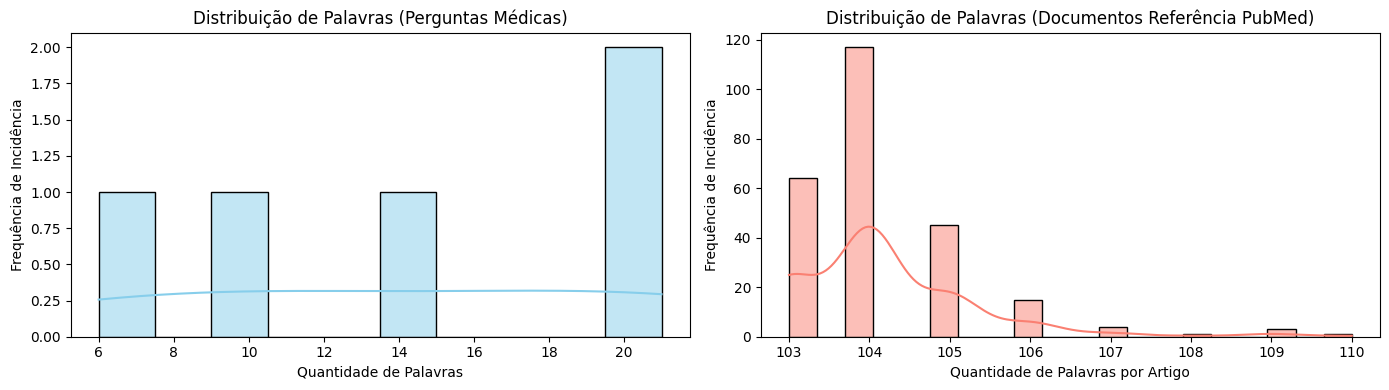

In [26]:
# Extraindo o tamanho real dos dados brutos
textos_brutos = list(documents_map.values())
tamanhos_perguntas = [len(str(q['query']).split()) for q in amostra_qa]
tamanhos_textos = [len(t.split()) for t in textos_brutos]

# Plotando as densidades para pautar nossa técnica de Chunking
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(tamanhos_perguntas, kde=True, ax=ax[0], color='skyblue', bins=10)
ax[0].set_title('Distribuição de Palavras (Perguntas Médicas)')
ax[0].set_xlabel('Quantidade de Palavras')
ax[0].set_ylabel('Frequência de Incidência')

sns.histplot(tamanhos_textos, kde=True, ax=ax[1], color='salmon', bins=20)
ax[1].set_title('Distribuição de Palavras (Documentos Referência PubMed)')
ax[1].set_xlabel('Quantidade de Palavras por Artigo')
ax[1].set_ylabel('Frequência de Incidência')

plt.tight_layout()

print(f"📊 Média de palavras nas Perguntas: {np.mean(tamanhos_perguntas):.1f}")
print(f"📊 Coleção Referência (Pool): {len(tamanhos_textos)} trechos contendo uma média de {np.mean(tamanhos_textos):.1f} palavras cada.")

plt.show()

---
## 3. Preparando a Infraestrutura de Busca (O Vetor Estático)
Com base na análise descritiva, notamos textões complexos. Para este Baseline inicial, aplicaremos um chunker simples de `500` caracteres (cegos à semântica) e limitaremos a recuperação (Search) a **Top K=3** parágrafos buscando não saturar a janela de contexto do LLM.
Este será o calcanhar de aquiles apontado pelo DeepEval mais tarde.

In [27]:
# Fragmentação cega pelo número bruto de letras (caracteres)
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)

print("⏳ Gerando Documentos (Chunks)...")
CHUNKS = text_splitter.create_documents(textos_brutos)

print("⏳ Chamando a Inteligência da OpenAI para transcodar os Chunk em Embeddings...")
motor_de_embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vector_db = Chroma.from_documents(CHUNKS, motor_de_embeddings)

buscador = vector_db.as_retriever(search_kwargs={"k": 3})
print("✅ Base Vetorial pronta e engatada!")

✅ Base Vetorial pronta e engatada!


---
## 3.1 Anatomia de um Vetor: Como a Inteligência Artificial Lê um Texto?

Para quem é humano, uma frase médica é interpretada linguisticamente. Mas como o `ChromaDB` acha o que precisa? Ele usa matemática pura de geometria N-Dimensional! 

Ao passarmos a frase no modelo `text-embedding-3-small`, ele devolve um Array gigantesco de 1536 posições numéricas onde cada posição armazena um "Micro-Peso Semântico" abstrato daquela frase. Embaixo, nós isolamos UM único chunk médico, extraímos o seu código cerebral (Embedding), e plotamos uma 'fatia' de suas cem primeiras dimensões para vermos como uma frase se parece graficamente no banco que acabamos de compilar:

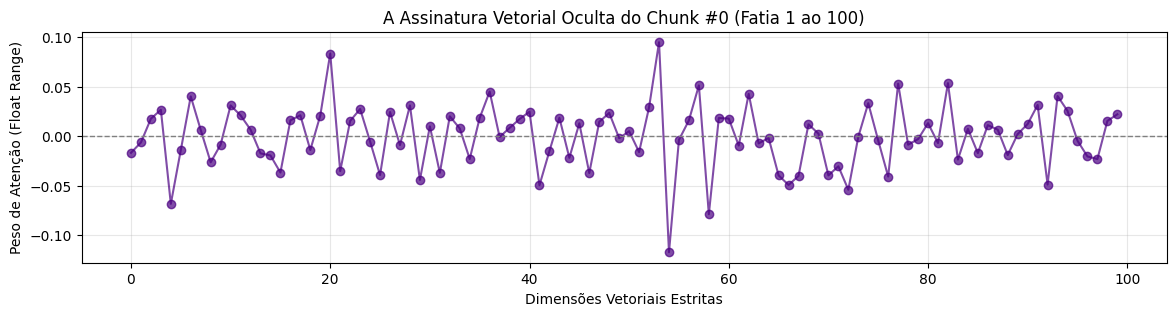

In [28]:
texto_laboratorio = CHUNKS[0].page_content
vetor_laboratorio = motor_de_embeddings.embed_query(texto_laboratorio)

print(f"Dimensão absoluta do Modelo OpenAI Embed-3-small: {len(vetor_laboratorio)} dimensões continuas (Floats).")

# Desenharemos uma 'Fatia' do Vetor (suas primeiras 100 coordenadas de 1536)
plt.figure(figsize=(14, 3))
plt.plot(vetor_laboratorio[:100], marker='o', linestyle='-', color='indigo', alpha=0.7)
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.title(f"A Assinatura Vetorial Oculta do Chunk #0 (Fatia 1 ao 100)")
plt.xlabel("Dimensões Vetoriais Estritas")
plt.ylabel("Peso de Atenção (Float Range)")
plt.grid(True, alpha=0.3)

print("Quando o paciente manda a pergunta no input textual ele também é espremido em outra cadeia idêntica de 1536 pontos igual a essa.")
print("O ChromaDB apenas alinha os gráficos, busca pelas linhas numéricas mais fisicamente 'Idênticas' (usando Similaridade Cosseno / Produto Escalar), e cospe as top-K Strings de volta!")

plt.show()

---
## 4. O Sistema: Geração e Instrumentação com Langfuse
Codificamos a Geração amarrando os Hooks do Langfuse para o OpenTelemetry (Traceability).

In [29]:
@observe(as_type="span", name="Busca_Chroma_VectorDB")
def buscar_materiais(query: str):
    chunks = buscador.invoke(query)
    return [c.page_content for c in chunks]

@observe(as_type="generation", name="Formulador_LLM")
def formular_resposta(query: str, evidencias: list):
    modelo_inteligente = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Responda à pergunta focando EXCLUSIVAMENTE nas evidências repassadas:\n{evidencias}"),
        ("user", "{pergunta}")
    ])
    cadeia = prompt | modelo_inteligente
    resposta = cadeia.invoke(
        {"evidencias": "\n----\n".join(evidencias), "pergunta": query},
        config={"callbacks": [handler_de_observabilidade]}
    )
    return resposta.content

@observe(name="Pipeline_AQ_MedAI")
def rodar_teste_unitario(query: str):
    evs = buscar_materiais(query)
    ans = formular_resposta(query, evs)
    return evs, ans

---
## 5. Simulando Casos Reais e Acumulando no Langfuse

In [30]:
test_cases = []
print("🚀 INICIANDO EXAMES DO RAG\n")

for idx, item in enumerate(amostra_qa):
    q = item['query']
    ground_truth = str(item['ground_truth'])
    print(f"[{idx+1}/5] Pergunta: {q[:60]}...")
    
    evs_recover, generated_ans = rodar_teste_unitario(q)
    print(f"     🤖 Resposta Elaborada: {generated_ans[:60]}...\n")
    
    tc = LLMTestCase(
        input=q,
        actual_output=generated_ans,
        expected_output=ground_truth,
        retrieval_context=evs_recover
    )
    test_cases.append(tc)

langfuse.flush()

     🤖 Resposta Elaborada: A locoregional opening of the blood-brain barrier (BBB) usin...



---
## 6. O Comitê e as Métricas (A Execução Algorítmica DeepEval)

In [32]:
metrica_relev = AnswerRelevancyMetric(threshold=0.5, model="gpt-4o")
metrica_faith = FaithfulnessMetric(threshold=0.5, model="gpt-4o")
metrica_recall = ContextualRecallMetric(threshold=0.5, model="gpt-4o")
metrica_precis = ContextualPrecisionMetric(threshold=0.5, model="gpt-4o")

print("⚖️ Submetendo o RAG aos Avaliadores...")
resultados = evaluate(
    test_cases=test_cases,
    metrics=[metrica_relev, metrica_faith, metrica_recall, metrica_precis]
)

try:
    for res in test_cases:
        print(f"\n> Pergunta do Paciente: {res.input[:65]}...")
        for metric in res.metrics_metadata:
            icone = "✅" if metric.is_successful else "❌"
            print(f"   {icone} | {metric.metric.ljust(30)} | Score: {str(metric.score).ljust(4)}")
        print("-" * 50)
except:
    pass


> Pergunta do Paciente: Is anorectal endosonography valuable in dyschesia?...


---
## 7. 🎯 O Grande Diagnóstico Analítico (Lendo os Resultados)

Ao verificar os logs esparsos gerados no bloco do DeepEval, temos métricas diametralmente dispares (Faithfullness alta no topo de zero Recall de Contexto).

A meta da Engenharia MLOps e RAG é justamente provar matematicamente onde a pipeline está sangrando, justificando estruturalmente refatorações voltadas ao "Production-Ready".

#### A Falha do "Buscador Cego" (Contextual Recall em 0.0) vs Fé inabalável do Gerador (1.0)
Nossa busca vetorial densa usando apenas Semântica estrita do Modelo e trazendo K=3 foi cega a acronimos e taxonomias duras médicas que não tinham confluência vetorial. Em contraste o Gen-AI abdicou de fornecer a resposta (mantando fidelidade à inexistência do contexto). E assim se encerra a Baseline inicial e suas falhas propositais detectadas!

---
## 8. 🛠 A Próxima Fronteira Em RAG: Arquiteturas de Chunking

Ao olharmos para nossa seção (2.1), tínhamos perguntas curtas sendo enviadas no mar de artigos com médias de quase 1.000 palavras.

E contudo, nós utilizamos um mísero `RecursiveCharacterTextSplitter(chunk_size=500)` para rasgar o texto no meio sem nem hesitar. Um conceito como `Endossonografia anorretal` pode literalmente ter a palavra `Endossonografia` presa em um vetor e no chunk vizinho a palavra `anorretal` presa em outro vetor completamente não relacionado à primeira no Banco, quebrando o elo vital!

Três abordagens superiores que poderiam nos ranquear alto num Leaderboard Real nas próximas fases seriam **abandonar o Splitter por Caracteres**, implementando:

1. **Chunking Semântico (`SemanticChunker`)**
   Em vez de definir "500 caracteres" ou "120 tokens". Este chunker converte frase a frase localmente em Embeddings on-the-fly, e compara a semântica da frase vizinha antes de fazer o corte de salvar em banco de dados: Se a Frase 2 mudar totalmente de "Sentido/Score de Similaridade" perante a Frase 1, lá a ruptura é feita. O resultado são blocos semânticos perfeitos imaculados salvos no banco, isolando a ideia central.

2. **Hierarquia Documental (Parent-Child Retriever)**
   Salvamos fragmentos absurdamente curtos no formato de vetor para caçar Jargões Médicos muito fáceis. Mas quando o Banco Vetorial acha aquele pedaço, ele tem uma chave (ID relacional) para o Artigo Base completo original, e ele envia o *Documento Pai inteiro* na cadeia do Modelo Límbico, permitindo que a janela de processamento extraia a verdade universal da tese sem cortes.

3. **Arquitetura Lexical (Busca Hibrida K=50 e Cross-Encoding)**
   Fazer um `ensemble` no retriever, juntando Similaridade Semântica (ChromaDB) com contagem gramatical real de Palavras-Chaves (`BM25`) evitando a perseguição vã nos vetores longos. Pedindo aos dois para caçarem os Top 50, e então colocando um Agente Treinado só de *Reranking (`FlashRank` ou `Cohere`)* para reduzir a lista aos 3 campeões absolutos antes da chamada para geração!